In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gff3_parser
from IPython.display import display
sys.path.append(os.path.abspath("..")) 
from prokaryotic.id_matching import (
    clean_id, parse_gbk_identifiers, safe_uniprot_mapping, 
    smart_eggnog_mapping, calculate_id_metrics
)

ORGANISMS = {
    "bacillus": "B. subtilis",
    "e_coli": "E. coli"
}

ORGANISM_TAXIDS = {
    "e_coli": "562",
    "bacillus": "1423",
}

TOOLS_TO_EVALUATE = ['Prokka', 'Bakta', 'PGAP', 'eggNOG']


  Evaluating: B. subtilis

Loading Data and Parsing GBK/GFF files
Executing UniProt API Mapping
  > Mapping: RefSeq_Protein -> UniProtKB (4091 IDs)...
    -> Success: Mapped 4240 IDs via RefSeq_Protein.
  > Mapping: STRING -> UniProtKB (6728 IDs)...
    -> Success: Mapped 3633 IDs via STRING.
  > Mapping: Gene Name -> UniProtKB (3095 IDs)...
    -> Success: Mapped 7535 IDs via Gene Name.
  > Mapping: EMBL/GenBank/DDBJ -> UniProtKB (690 IDs)...
    -> Success: Mapped 0 IDs via EMBL/GenBank/DDBJ.
Integrating mapped identifiers
Mapping to UniRef100 Clusters
  > Mapping: UniProtKB_AC-ID -> UniRef100 (6082 IDs)...
    -> Success: Mapped 6080 IDs via UniProtKB_AC-ID.


,Annotation Tool,Exact UniProt Rate (%),UniRef100 Cluster Rate (%),Ref. IDs Available (100%),UniProt Matches (n),Cluster Matches (n)
0,Prokka,39.950000,39.950000,4170,1666,1666
1,Bakta,89.110000,89.160000,4170,3716,3718
2,PGAP,39.860000,67.430000,4170,1662,2812
3,eggNOG,87.070000,88.060000,4170,3631,3672



  Evaluating: E. coli

Loading Data and Parsing GBK/GFF files
Executing UniProt API Mapping
  > Mapping: RefSeq_Protein -> UniProtKB (4052 IDs)...
    -> Success: Mapped 8069 IDs via RefSeq_Protein.
  > Mapping: STRING -> UniProtKB (7540 IDs)...
    -> Success: Mapped 1476 IDs via STRING.
  > Mapping: GI number -> UniProtKB (1204 IDs)...
    -> Success: Mapped 1203 IDs via GI number.
  > Mapping: Gene Name -> UniProtKB (4860 IDs)...
    -> Success: Mapped 122226 IDs via Gene Name.
  > Mapping: EMBL/GenBank/DDBJ -> UniProtKB (1206 IDs)...
    -> Success: Mapped 0 IDs via EMBL/GenBank/DDBJ.
Integrating mapped identifiers
Mapping to UniRef100 Clusters
  > Mapping: UniProtKB_AC-ID -> UniRef100 (8157 IDs)...
    -> Success: Mapped 8153 IDs via UniProtKB_AC-ID.


,Annotation Tool,Exact UniProt Rate (%),UniRef100 Cluster Rate (%),Ref. IDs Available (100%),UniProt Matches (n),Cluster Matches (n)
0,Prokka,66.830000,67.850000,4278,2859,2900
1,Bakta,88.850000,90.130000,4278,3801,3852
2,PGAP,64.050000,82.220000,4278,2740,3514
3,eggNOG,29.270000,44.810000,4278,1252,1915


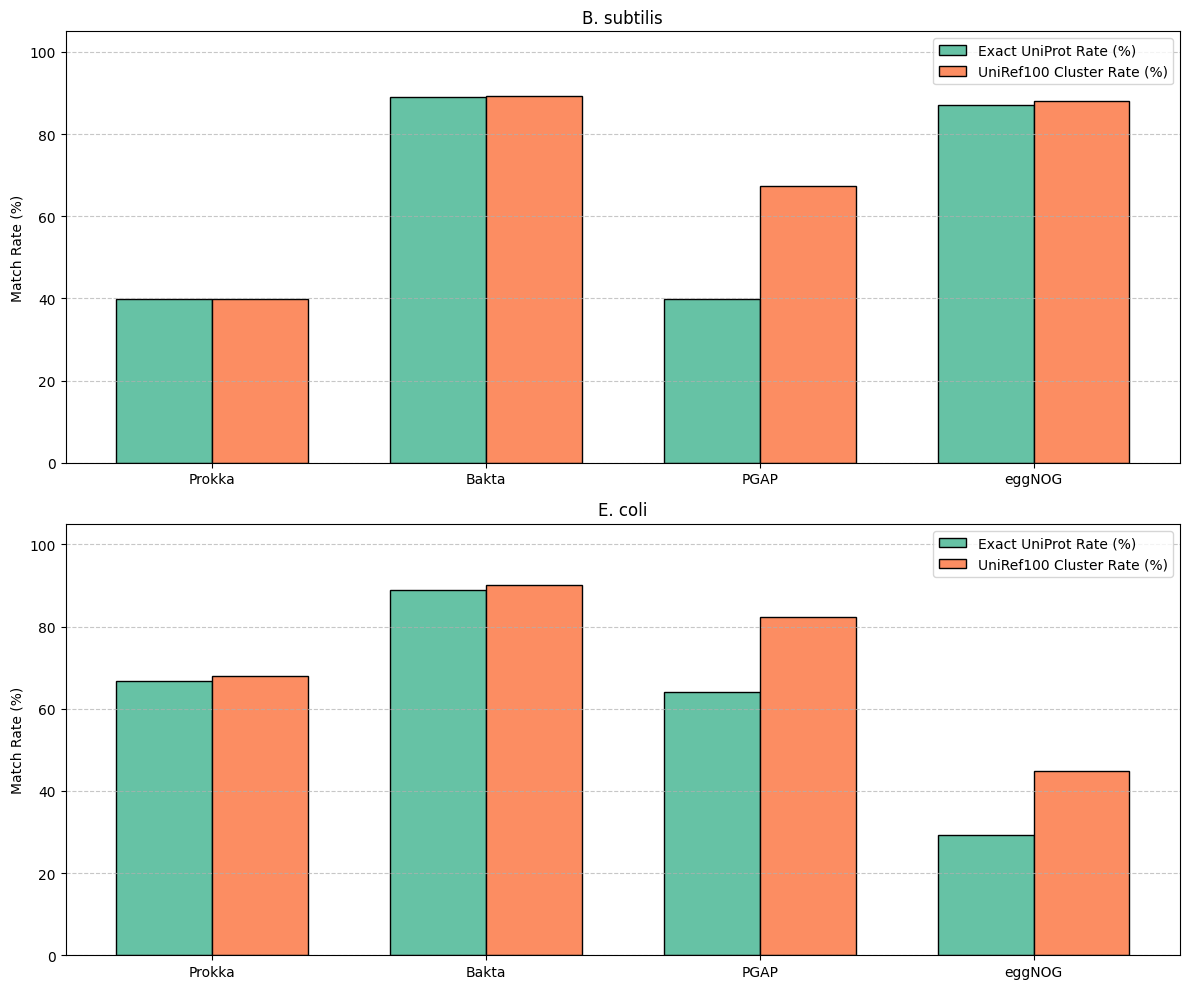

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

org_list = list(ORGANISMS.keys())

for idx, (org_id, org_name) in enumerate(ORGANISMS.items()):
    print(f"\n=========================================")
    print(f"  Evaluating: {org_name}")
    print(f"=========================================\n")
    
    PROKKA_GBK = f"../results/prokka/{org_id}_prokka/{org_id}.gbk"
    PGAP_GBK = f"../results/pgap/{org_id}_pgap/annot.gbk"
    BAKTA_GBK = f"../results/bakta/{org_id}_bakta/{org_id}.gbff"
    GENBANK_GBFF = f"{org_id}_data/{org_id}_genbank.gbff"
    EGGNOG_GFF = f"../results/eggnog/{org_id}_eggnog/{org_id}.emapper.decorated.gff"
    CONCORDANT_CSV = f"{org_id}_data/{org_id}_concordant_CDS.csv"
    
    if not os.path.exists(CONCORDANT_CSV):
        print(f"Skipping {org_id}.")
        continue

    print("Loading Data and Parsing GBK/GFF files")
    df_func = pd.read_csv(CONCORDANT_CSV)
    df_func.drop(columns=[col for col in df_func.columns if 'product_' in col or 'Start' in col or 'End' in col or 'Strand' in col], inplace=True, errors='ignore')
    
    df_gbff = parse_gbk_identifiers(GENBANK_GBFF, "Reference")
    df_prokka = parse_gbk_identifiers(PROKKA_GBK, "Prokka")
    df_bakta = parse_gbk_identifiers(BAKTA_GBK, "Bakta")
    df_pgap = parse_gbk_identifiers(PGAP_GBK, "PGAP")
    
    eggnog_df = gff3_parser.parse_gff3(EGGNOG_GFF, parse_attributes=True, verbose=False)
    eggnog_df["orf_id"] = eggnog_df.apply(lambda row: f"{row['Start']}_{row['End']}_{row['Strand']}", axis=1)
    
    eggnog_ids_dict = {}
    for _, row in eggnog_df.iterrows():
        target = row.get("em_target", np.nan)
        pref = row.get("em_Preferred_name", np.nan)
        eggnog_ids_dict[row["orf_id"]] = [x for x in [target, pref] if pd.notna(x) and str(x).strip() != ""]
        
    df_func["eggNOG_candidates"] = df_func["orf_id"].map(eggnog_ids_dict)
    
    for df in [df_gbff, df_prokka, df_bakta, df_pgap]:
        df_func = pd.merge(df_func, df, on='orf_id', how='left')
        
    df_func = df_func[df_func['Reference_ID'].notna()]

    print("Executing UniProt API Mapping")
    pgap_raw = df_func['PGAP_ID'].dropna().apply(clean_id).tolist()
    
    eggnog_raw = []
    for cands in df_func["eggNOG_candidates"].dropna(): eggnog_raw.extend(cands)
    eggnog_raw = list(set(eggnog_raw))
    
    df_pgap_uniprot = safe_uniprot_mapping(pgap_raw, from_db='RefSeq_Protein', to_db='UniProtKB')
    df_eggnog_uniprot = smart_eggnog_mapping(eggnog_raw, tax_id=ORGANISM_TAXIDS[org_id])

    print("Integrating mapped identifiers")
    dict_pgap = dict(zip(df_pgap_uniprot['From'], df_pgap_uniprot['To'])) if not df_pgap_uniprot.empty else {}
    dict_eggnog = dict(zip(df_eggnog_uniprot['From'], df_eggnog_uniprot['To'])) if not df_eggnog_uniprot.empty else {}

    def get_best_eggnog(candidates):
        if not isinstance(candidates, list): return np.nan
        for cand in candidates:
            if cand in dict_eggnog: return dict_eggnog[cand]
        return np.nan

    df_func['UniProt_PGAP'] = df_func['PGAP_ID'].apply(lambda x: dict_pgap.get(clean_id(x), np.nan))
    df_func['UniProt_Bakta'] = df_func['Bakta_ID'].apply(clean_id)
    df_func['UniProt_Prokka'] = df_func['Prokka_ID'].apply(clean_id)
    df_func['UniProt_Reference'] = df_func['Reference_ID'].apply(clean_id)
    df_func['UniProt_eggNOG'] = df_func['eggNOG_candidates'].apply(get_best_eggnog)

    print("Mapping to UniRef100 Clusters")
    all_uniprot = list(set(
        df_func['UniProt_Bakta'].dropna().tolist() + df_func['UniProt_Prokka'].dropna().tolist() + 
        df_func['UniProt_Reference'].dropna().tolist() + df_func['UniProt_PGAP'].dropna().tolist() + 
        df_func['UniProt_eggNOG'].dropna().tolist()
    ))
    
    df_uniref = safe_uniprot_mapping(all_uniprot, from_db='UniProtKB_AC-ID', to_db='UniRef100')
    dict_uniref = dict(zip(df_uniref['From'], df_uniref['To'])) if not df_uniref.empty else {}

    for tool in ['PGAP', 'eggNOG', 'Bakta', 'Prokka', 'Reference']:
        df_func[f'Cluster_{tool}'] = df_func[f'UniProt_{tool}'].apply(lambda x: dict_uniref.get(x, np.nan))

    df_metrics = calculate_id_metrics(df_func, tools=TOOLS_TO_EVALUATE)
    
    display(df_metrics.style.background_gradient(cmap='Blues', subset=['Exact UniProt Rate (%)', 'UniRef100 Cluster Rate (%)']))

    ax = axes[idx]
    
    x = np.arange(len(df_metrics))
    width = 0.35
    
    ax.bar(x - width/2, df_metrics['Exact UniProt Rate (%)'], width, label='Exact UniProt Rate (%)', color='#66c2a5', edgecolor='black')
    ax.bar(x + width/2, df_metrics['UniRef100 Cluster Rate (%)'], width, label='UniRef100 Cluster Rate (%)', color='#fc8d62', edgecolor='black')
    
    ax.set_ylabel('Match Rate (%)')
    ax.set_title(f'{org_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(df_metrics['Annotation Tool'], rotation=0)
    ax.set_ylim(0, 105)
    ax.legend()

plt.tight_layout()
plt.show()